# INbreast EDA

## Imports

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pydicom

## Metadata File Review

The INbreast dataset provides a single CSV file with metadata for all cases:

- `datasets/INbreast Release 1.0/INbreast.csv`

The dataset includes:
- 410 mammography images from 115 cases
- Images in DICOM format
- ROI masks and XML annotations for findings
- Medical reports

In [2]:
INBREAST_ROOT = Path("../datasets/INbreast Release 1.0")

In [3]:
inbreast_df = pd.read_csv(INBREAST_ROOT / "INbreast.csv", sep=";")
inbreast_df.head()

,Patient ID,Patient age,Laterality,View,Acquisition date,File Name,ACR,Bi-Rads
0,removed,removed,R,CC,201001,22678622,4,1
1,removed,removed,L,CC,201001,22678646,4,3
2,removed,removed,R,MLO,201001,22678670,4,1
3,removed,removed,L,MLO,201001,22678694,4,3
4,removed,removed,R,CC,201001,22614074,2,5


In [4]:
print(f"Total number of images: {len(inbreast_df)}")
print(f"Number of unique patients: {inbreast_df['Patient ID'].nunique()}")
print(f"\nDataset shape: {inbreast_df.shape}")

Total number of images: 410
Number of unique patients: 1

Dataset shape: (410, 8)


In [5]:
# Check the columns
print("Columns:")
for col in inbreast_df.columns:
    print(f"  - {col}")

Columns:
  - Patient ID
  - Patient age
  - Laterality
  - View
  - Acquisition date
  - File Name
  - ACR
  - Bi-Rads


## EDA

Start by analysis key characteristics of the dataset.

### BI-RADS Assessment Distribution

The BI-RADS (Breast Imaging Reporting and Data System) assessment category indicates the level of suspicion:
- 1: Negative
- 2: Benign
- 3: Probably benign
- 4a, 4b, 4c: Suspicious
- 5: Highly suggestive of malignancy
- 6: Known biopsy-proven malignancy

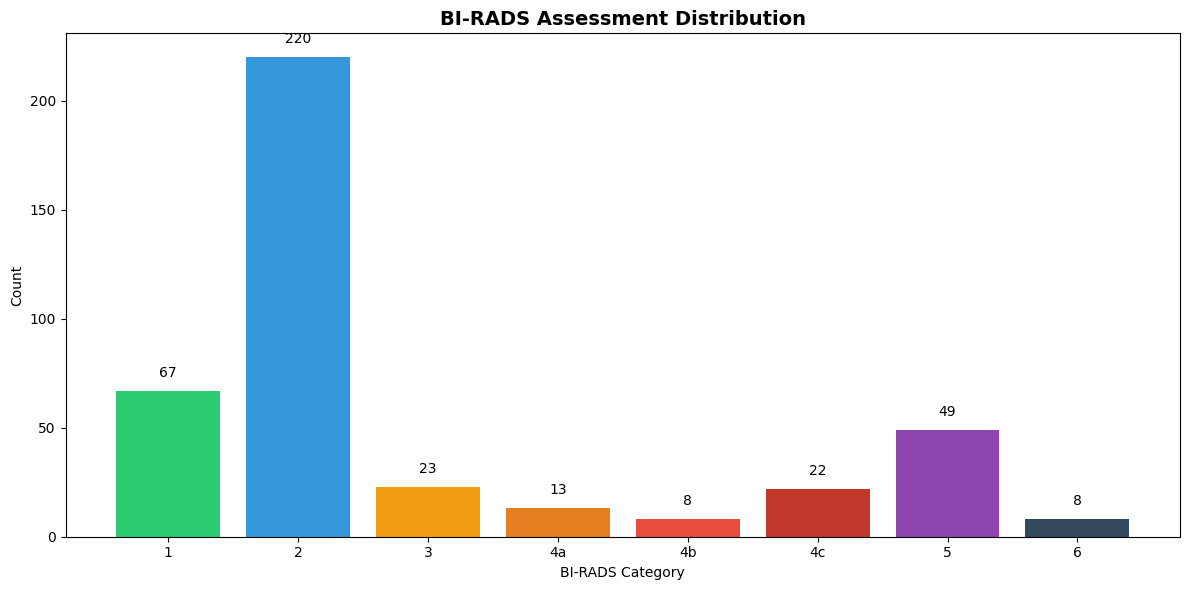

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

birads_counts = inbreast_df['Bi-Rads'].value_counts().sort_index()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c', '#c0392b', '#8e44ad', '#34495e']
ax.bar(birads_counts.index.astype(str), birads_counts.values, color=colors[:len(birads_counts)])
ax.set_title('BI-RADS Assessment Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('BI-RADS Category')
ax.set_ylabel('Count')
for i, v in enumerate(birads_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Let's create binary labels for classification:
- Benign: BI-RADS 1, 2, 3
- Malignant: BI-RADS 4a, 4b, 4c, 5, 6

In [7]:
def classify_birads(birads):
    if birads in [1, 2, 3]:
        return 'Benign'
    elif birads in ['4a', '4b', '4c', 4, 5, 6]:
        return 'Malignant'
    else:
        return 'Unknown'

inbreast_df['pathology'] = inbreast_df['Bi-Rads'].apply(classify_birads)

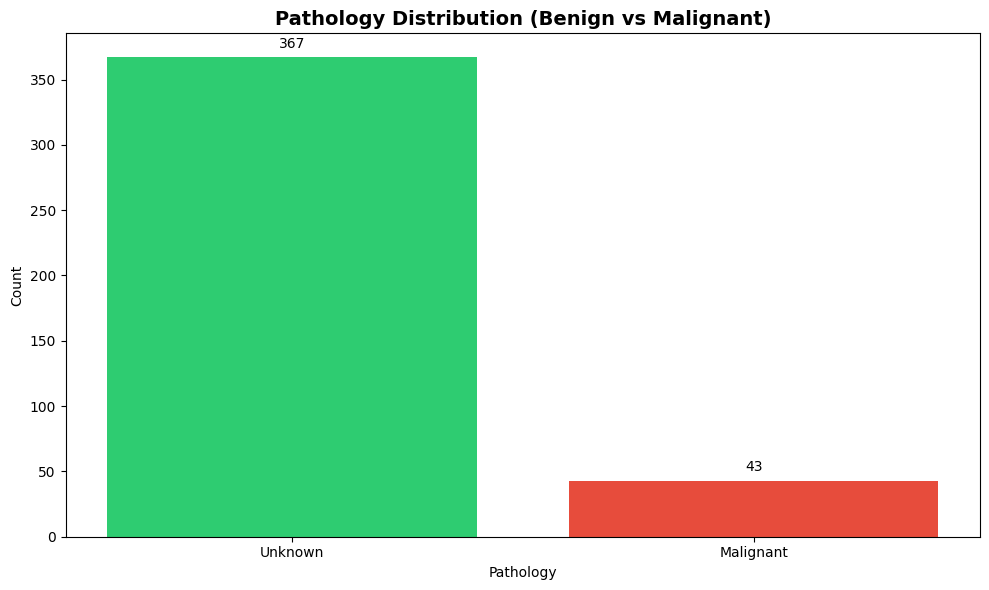

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

pathology_counts = inbreast_df['pathology'].value_counts()
colors_pathology = ['#2ecc71', '#e74c3c', '#95a5a6']
ax.bar(pathology_counts.index, pathology_counts.values, color=colors_pathology[:len(pathology_counts)])
ax.set_title('Pathology Distribution (Benign vs Malignant)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pathology')
ax.set_ylabel('Count')
for i, v in enumerate(pathology_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### ACR Breast Density Distribution

The ACR (American College of Radiology) breast density classification:
- 1: Almost entirely fatty
- 2: Scattered fibroglandular densities
- 3: Heterogeneously dense
- 4: Extremely dense

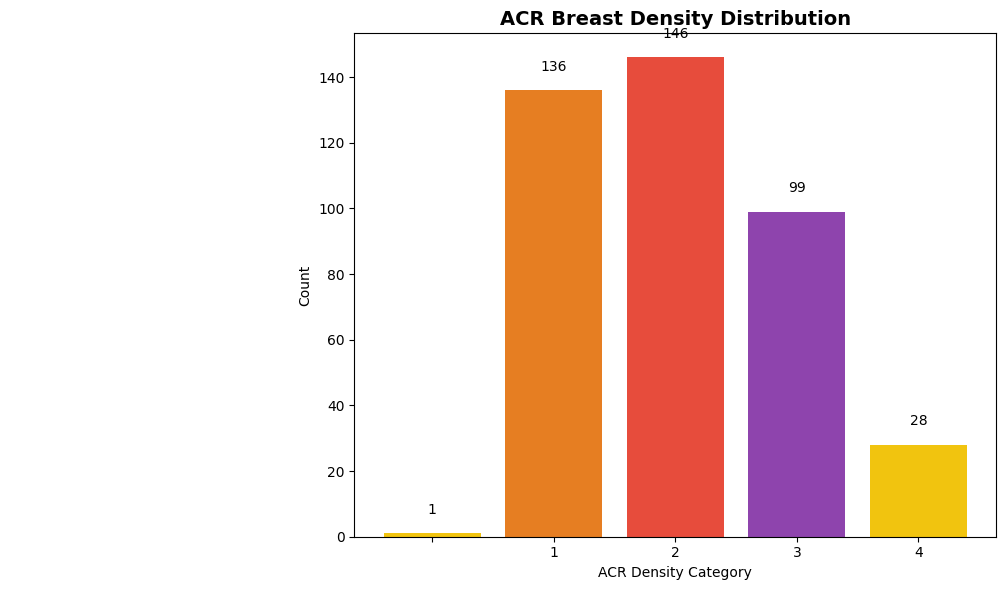

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

acr_counts = inbreast_df['ACR'].value_counts().sort_index()
# Filter out the empty string if it exists
acr_counts = acr_counts[acr_counts.index != '']
colors_acr = ['#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
ax.bar(acr_counts.index.astype(str), acr_counts.values, color=colors_acr)
ax.set_title('ACR Breast Density Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('ACR Density Category')
ax.set_ylabel('Count')
for i, v in enumerate(acr_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Image View Distribution

Standard mammography views:
- CC: Craniocaudal view
- MLO: Mediolateral oblique view

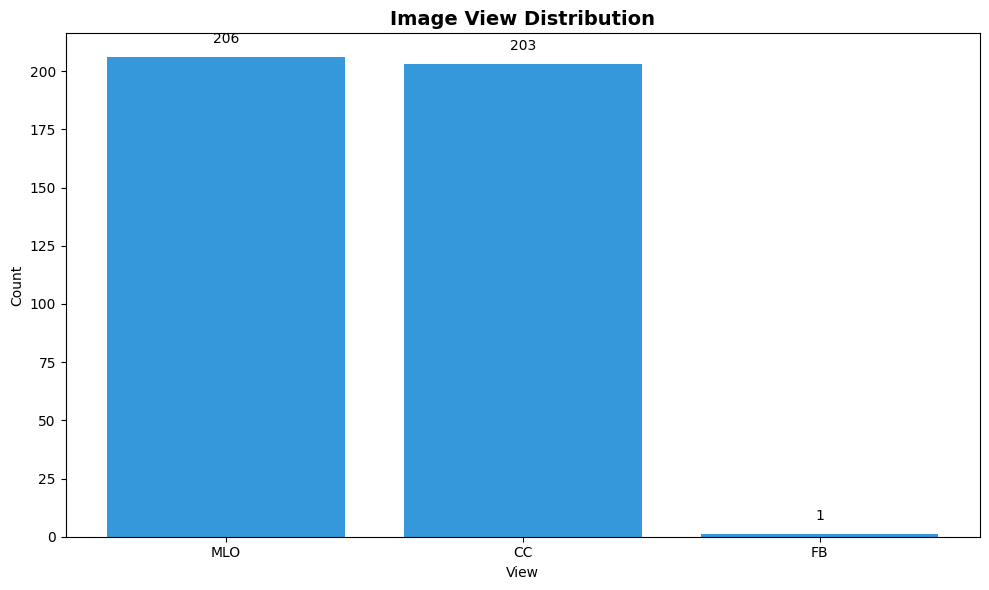

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

view_counts = inbreast_df['View'].value_counts()
ax.bar(view_counts.index, view_counts.values, color='#3498db')
ax.set_title('Image View Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('View')
ax.set_ylabel('Count')
for i, v in enumerate(view_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Laterality Distribution

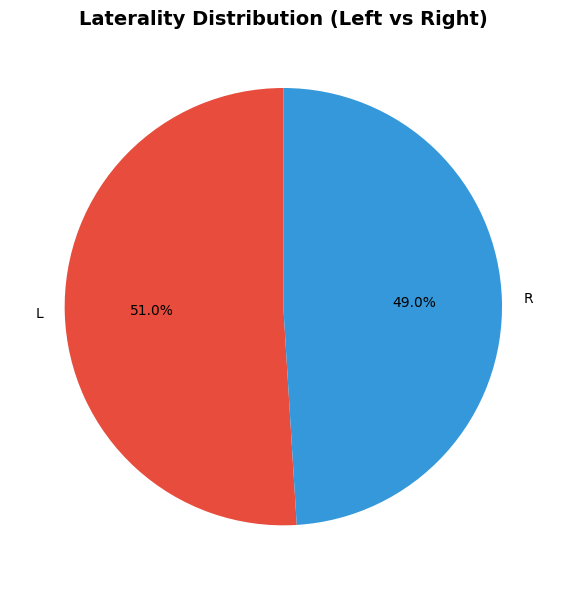

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

laterality_counts = inbreast_df['Laterality'].value_counts()
ax.pie(laterality_counts.values, labels=laterality_counts.index, autopct='%1.1f%%',
       colors=['#e74c3c', '#3498db'], startangle=90)
ax.set_title('Laterality Distribution (Left vs Right)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Cross-Analysis: BI-RADS by ACR Density

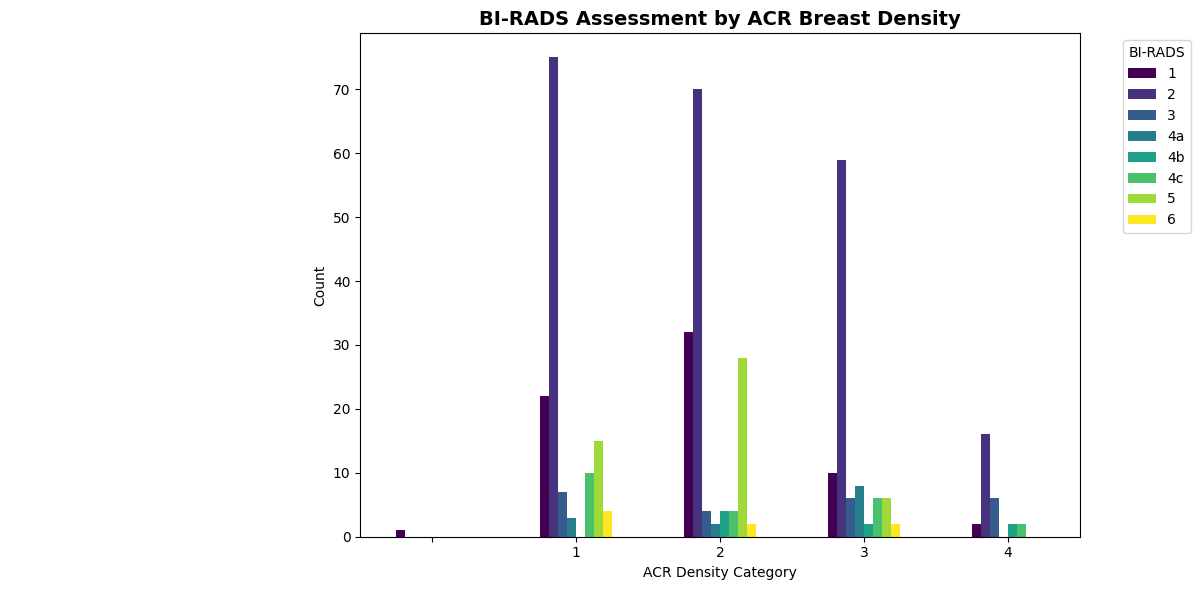

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

# Filter out empty ACR values
df_filtered = inbreast_df[inbreast_df['ACR'] != '']
birads_acr = pd.crosstab(df_filtered['ACR'], df_filtered['Bi-Rads'])
birads_acr.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('BI-RADS Assessment by ACR Breast Density', fontsize=14, fontweight='bold')
ax.set_xlabel('ACR Density Category')
ax.set_ylabel('Count')
ax.legend(title='BI-RADS', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Cross-Analysis: Pathology by View

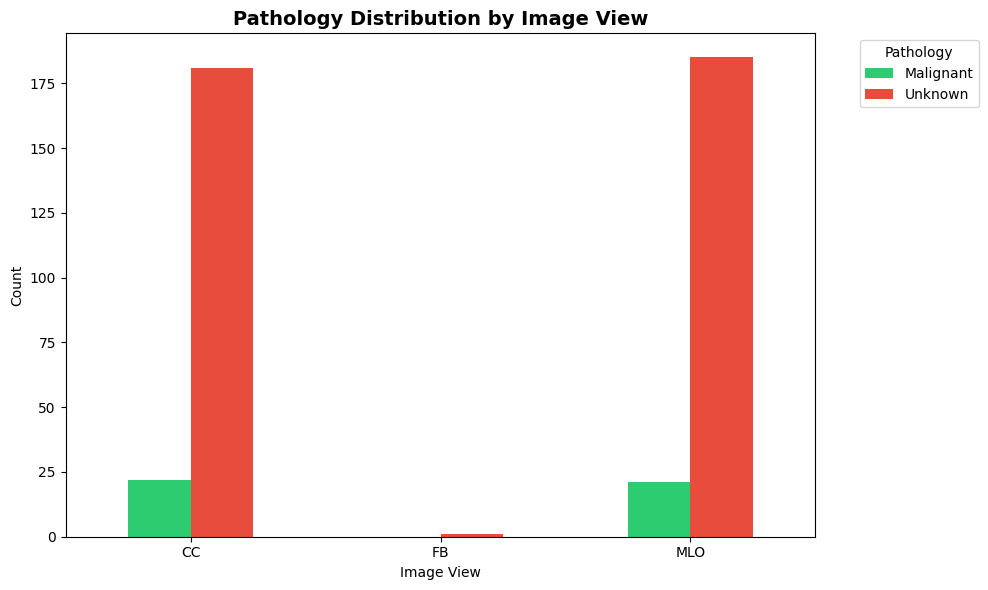

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

pathology_view = pd.crosstab(inbreast_df['View'], inbreast_df['pathology'])
pathology_view.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c', '#95a5a6'])
ax.set_title('Pathology Distribution by Image View', fontsize=14, fontweight='bold')
ax.set_xlabel('Image View')
ax.set_ylabel('Count')
ax.legend(title='Pathology', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Image Extraction and Visualization

Let's look at how to load and display DICOM images from the INbreast dataset.

In [59]:
# Get a sample image
sample_row = inbreast_df.iloc[1]
sample_filename = sample_row['File Name']
print(f"Sample image filename: {sample_filename}")

Sample image filename: 22678646


In [62]:
sample_row

Patient ID           removed
Patient age          removed
Laterality                 L
View                      CC
Acquisition date      201001
File Name           22678646
ACR                        4
Bi-Rads                    3
pathology            Unknown
Name: 1, dtype: object

In [60]:
# Construct the DICOM file path
dicom_path = files = list((INBREAST_ROOT / "AllDICOMs").rglob(f"{sample_filename}*.dcm"))[0]
print(f"DICOM path: {dicom_path}")
print(f"File exists: {dicom_path.exists()}")

DICOM path: ../datasets/INbreast Release 1.0/AllDICOMs/22678646_61b13c59bcba149e_MG_L_CC_ANON.dcm
File exists: True


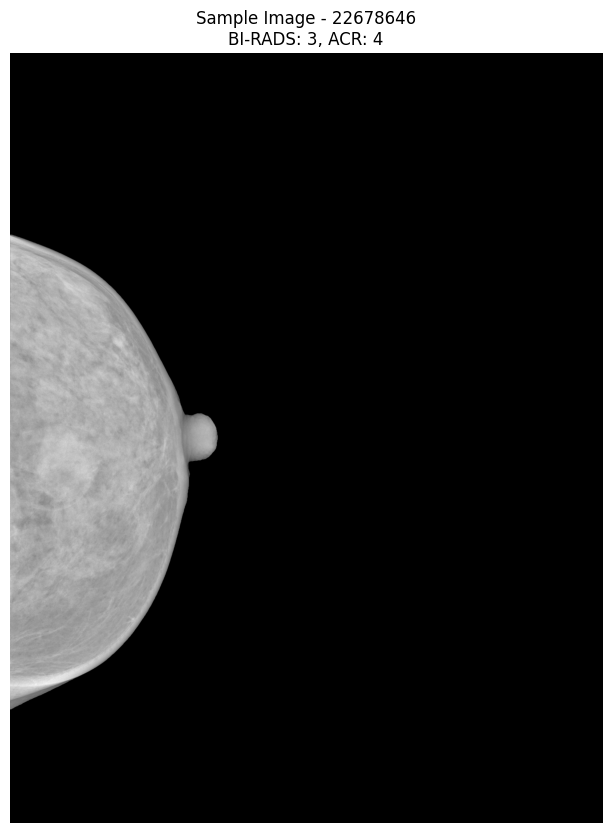

Image shape: (3328, 2560)
Pixel value range: [0, 2287]


In [61]:
# Load the DICOM file
if dicom_path.exists():
    dicom_data = pydicom.dcmread(dicom_path)
    img_array = dicom_data.pixel_array

    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(img_array, cmap='gray')
    plt.title(f"Sample Image - {sample_filename}\nBI-RADS: {sample_row['Bi-Rads']}, ACR: {sample_row['ACR']}")
    plt.axis('off')
    plt.show()

    print(f"Image shape: {img_array.shape}")
    print(f"Pixel value range: [{img_array.min()}, {img_array.max()}]")

## Questions

How do I find images across patients?

